# Business Problem
A global e-commerce company managing end-to-end order fulfillment for sporting goods is facing inconsistent delivery performance. Actual shipping timelines often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

## Desire Outcomes
The goal is to:

* Analyze delivery operations to identify **bottlenecks**.  

* Build a predictive system to reduce delays and optimize shipping decisions.  

* Improve overall profitability and operational efficiency.

## Dataset Description: Supply Chain & Logistics Records

This dataset captures the end-to-end journey of **172,765 transactions** from a global sporting goods retailer. It tracks every stage of the order lifecycle—from the moment a customer clicks "buy" to the final delivery at their door.

---

### 1. Data Categorization
The dataset has been refined to **21 high-impact features**, organized into four key areas:

* **🕒 Temporal (Time-Based) Data**
    * **Fields:** `order date (DateOrders)`, `shipping date (DateOrders)`
    * **Role:** Acts as the "heartbeat" of the data, used to calculate lead times and spot seasonal trends.
* **🚚 Logistics & Fulfillment**
    * **Fields:** `Days for shipping (real)`, `Days for shipment (scheduled)`, `Delivery Status`, `Shipping Mode`
    * **Role:** Measures the gap between the shipping "promise" and the actual "reality."
* **📦 Product Information**
    * **Fields:** `Product Name`, `Category Name`, `Product Price`
    * **Role:** Helps identify if specific categories (e.g., heavy equipment vs. apparel) are more prone to delays.
* **💰 Financials & Risk**
    * **Fields:** `Sales`, `Order Profit Per Order`, `Late_delivery_risk`
    * **Role:** Quantifies the financial cost of logistics failures and flags high-risk orders.

---

### 2. Data Quality & Preprocessing
To ensure the analysis is accurate and professional, the following steps were taken:

* **Relevance Filtering:** Removed "Canceled" orders to focus strictly on fulfillment performance.
* **Dimensionality Reduction:** Dropped **30+ redundant columns** (like personal emails and internal IDs) to eliminate noise and protect privacy.
* **Standardization:** Converted date fields into proper `datetime` objects for precise duration calculations.

---

In [1]:
#Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Set a professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [3]:
df = pd.read_csv('88QepNHUHH9SnnVFrjM2J6.csv', encoding = 'latin-1')

In [4]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


This data is the masster table which is formed after combinenig a lots of data from the diffrents small sub tables

In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

# Exploratoray Data Analysis (EDA)

In [6]:
# Overview of Data
print(f'number of rows {df.shape[0]}, number of columns {df.shape[1]}')
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum of duplicate values:', df.duplicated().sum())
print('\nNum of missing value (top 20):')
print(df.isna().sum().sort_values(ascending = False).head(20))

number of rows 180519, number of columns 53

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Prod

In [7]:
(df['Benefit per order'] == df['Order Profit Per Order']).value_counts()

True    180519
Name: count, dtype: int64

In [8]:
# Droping the columns which are not necessary for our analysis
columns_to_drop = [
    'Category Id',
    'Customer Email',
    'Customer Fname',
    'Customer Lname',
    'Customer Id',
    'Customer Street',
    'Customer City',
    'Customer Password',
    'Customer Zipcode',
    'Department Id',
    'Latitude',
    'Longitude',
    'Order Customer Id',
    'Order Id',
    'Order Item Cardprod Id',
    'Order Zipcode',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Id',
    'Order Item Product Price',
    'Order Item Total',
    'Order Item Quantity',
    'Product Card Id',
    'Product Category Id',
    'Product Description',
    'Product Image',
    'Product Status',
    'Order City',
    'Order Country',
    'Order State',
    'Product Status', # have only one value
    'Benefit per order', #identical to profit per order
    'Market'
]

# dropping the columns that are either fully missing, redundant, or have only one value
df = df.drop(columns = columns_to_drop)

# removing the cancle orders since they are not relavent fordelivery time analysis and may have different patterns then completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

# standered conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst = False)

# after data cleaning lets check the overview again to see how the data set is change
print(f'number of rows {df.shape[0]}, number of columns {df.shape[1]}')
print('\nNum of missing value (top 5):')
print(df.isna().sum().sort_values(ascending = False).head(5))


number of rows 172765, number of columns 21

Num of missing value (top 5):
Type                          0
order date (DateOrders)       0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [9]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Customer State,...,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,PR,...,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,PR,...,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,CA,...,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,CA,...,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,PR,...,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [10]:
# values counts for catogerical columns
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} values counts:')
        print(df[col].value_counts())


Type values counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) values counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) values counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status values counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk values counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country values counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment values counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status values counts:
Order Status
CO

In [11]:
df['order date (DateOrders)']

0        2018-01-31 22:56:00
1        2018-01-13 12:27:00
2        2018-01-13 12:06:00
3        2018-01-13 11:45:00
4        2018-01-13 11:24:00
                 ...        
180514   2016-01-16 03:40:00
180515   2016-01-16 01:34:00
180516   2016-01-15 21:00:00
180517   2016-01-15 20:18:00
180518   2016-01-15 18:54:00
Name: order date (DateOrders), Length: 172765, dtype: datetime64[ns]

In [26]:
df['order_week'].unique()

array(['Wednesday', 'Saturday', 'Friday', 'Tuesday', 'Sunday', 'Monday',
       'Thursday'], dtype=object)

In [25]:
# order processing time and delay
df['Oredr Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Oredr Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delay'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df['order_week'] = df['order date (DateOrders)'].dt.day_name()
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Oredr Processing Time,Delay,order_month,order_day,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,15.739803,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,8.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,16.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,23.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,31.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,8.823467,6.927276


In [13]:
df['Is_Delay'].value_counts()

Is_Delay
True     94523
False    78242
Name: count, dtype: int64

In [14]:
df["Profitability Flag"] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df["Profitability Flag"].value_counts(normalize = True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break-even    0.00646
Name: proportion, dtype: float64

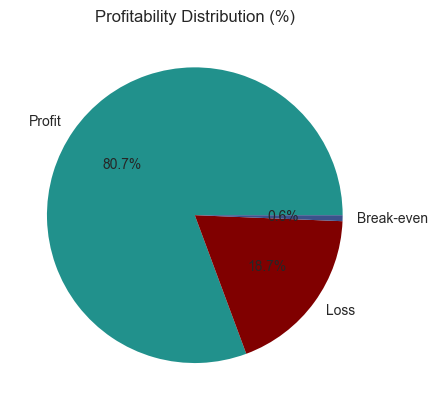

In [15]:
# Visulation of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize = True)*100
profit_counts.plot(kind = 'pie', autopct = '%1.1f%%', colors = [accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.savefig("profitability_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value > 1e3:
        return f'{value/1e3:.1f}k $'
    else:
        return f'{value:0.f}M $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time delivery %'] = (1 - float(metrics['Late Deliveries']/metrics['Total Orders']))*100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']/metrics['Total Orders'])*100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss Due to delay'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'{k}: {v:.2f}')
    else:
        print(f'{k}: {v}')

\--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss Due to delay: 2.1M $


## Profitability Vs Delivery Time Analysis

In [17]:
profit_matrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    ).reset_index()
)

In [18]:
profit_matrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [19]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize = True)
    .sort_index() * 100
).reset_index()

In [20]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Matrics by Delay Days



,Delay_Days,Percantage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


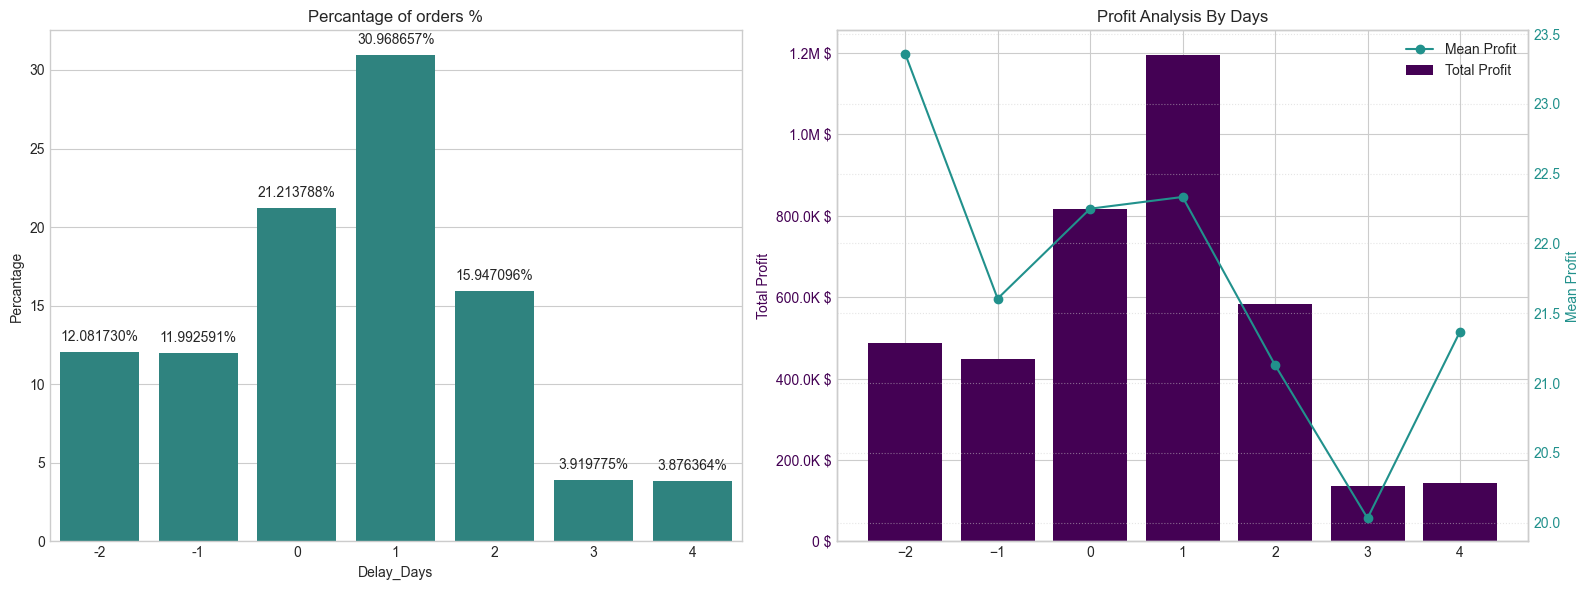

In [21]:
#plot of delay distribution profitability
delay_distribution.columns = ['Delay_Days', 'Percantage']
print('\nProfit Matrics by Delay Days\n')
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

# first subplot: Delay Distribution
sns.barplot(x = 'Delay_Days', y = 'Percantage', data = delay_distribution, color = accent_color, ax = ax1)
ax1.set_title('Delay Distribution')
ax1.set_title('Delay Days')
ax1.set_title('Percantage of orders %')

# percantage tex on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:1f}%', ha = 'center', va = 'bottom')

# Second subplot: profit analysis by delay days
ax2.set_ylabel('Total Profit', color = primary_color)
ax2.bar(profit_matrics['Delay'], profit_matrics['total_profit'], color = primary_color, label = 'Total Profit')
ax2.tick_params(axis = 'y', labelcolor = primary_color)

ax3 = ax2.twinx()

ax3.set_ylabel('Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

ax3.set_xlabel('Delay Days')
ax3.set_ylabel('Mean Profit', color = accent_color)
ax3.tick_params(axis = 'y', labelcolor = accent_color)
ax3.plot(profit_matrics['Delay'], profit_matrics['mean_profit'], color=accent_color, marker='o', label='Mean Profit')
ax3.set_title('Profit Analysis By Days')

# formare total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc = 'upper right')
ax3.grid(True, linestyle = ':', alpha = 0.5)

plt.tight_layout()
plt.savefig("delay_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Bottleneck Detection

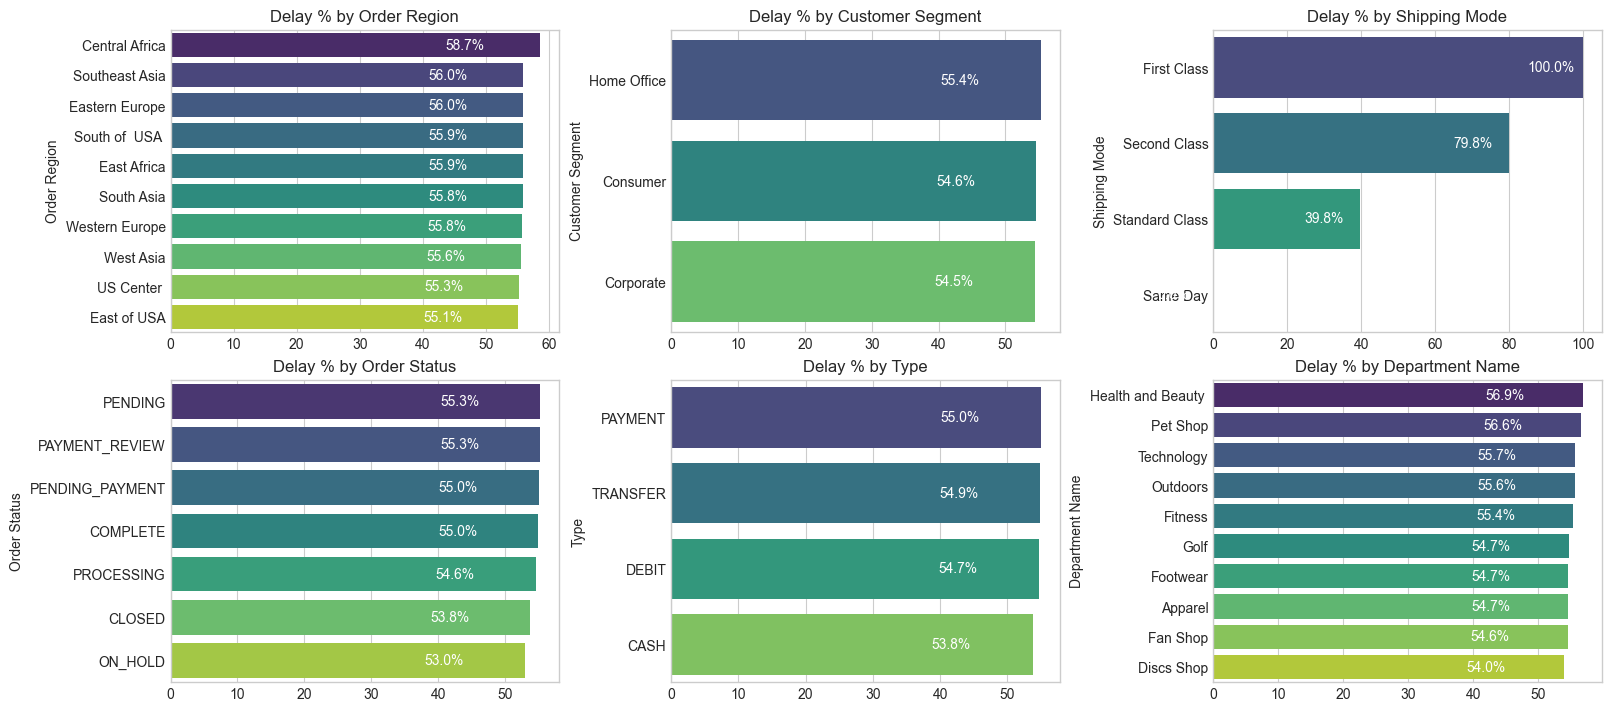

In [22]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders = ('Delay', 'count'),
        late_orders = ('Is_Delay', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending = False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize = (16, 7), constrained_layout = True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data = cat_df,
        x = 'delay_pct',
        y = category,
        ax = ax,
        palette = 'viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f'{row['delay_pct']:.1f}%', va = 'center', fontsize = 10, color = 'white')

plt.savefig("bottelneck.png", dpi=300, bbox_inches='tight')
plt.show()

# Root Cause Analysis

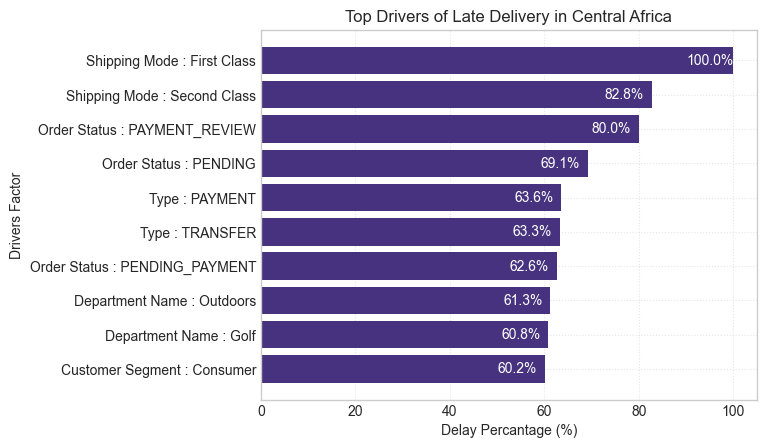

In [23]:
# top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders = ('Delay', 'count'),
                late_orders = ('Is_Delay', 'sum'),
                avg_delay = ('Delay', 'mean')
            ).reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Lavel'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(temp[['Driver', 'Factor_Lavel', 'avg_delay', 'total_orders', 'delay_pct']])

    # combine all drivers
    final_df = pd.concat(all_factors)

    # top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending = False).head(10)
    plt.figure()

    bars = plt.barh(top_factors['Factor_Lavel'], top_factors['delay_pct'])

    plt.xlabel('Delay Percantage (%)')
    plt.ylabel('Drivers Factor')
    plt.title(f'Top Drivers of Late Delivery in {region}')
    plt.grid(True, linestyle = ':', alpha = 0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%',
                va = 'center', fontsize = 10, color = 'white')
    plt.savefig("regional.png", dpi=300, bbox_inches='tight')    
    plt.show()
    
top_drivers_for_region('Central Africa')
    

# Time base-Analysis

In [29]:
# Delay percantage by month, day of week, hour

delay_by_month = (
    df.groupby('order_month')['Is_Delay']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delay'] * 100

delay_by_week = (
    df.groupby('order_week')['Is_Delay']
    .mean()
    .reset_index()
) 
delay_by_week['delay_pct'] = delay_by_week['Is_Delay'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delay']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delay'] * 100

In [30]:
delay_by_week

,order_week,Is_Delay,delay_pct
0,Friday,0.544884,54.488442
1,Monday,0.555338,55.533838
2,Saturday,0.542619,54.261937
3,Sunday,0.551524,55.152418
4,Thursday,0.547202,54.720188
5,Tuesday,0.539841,53.984137
6,Wednesday,0.548452,54.845175


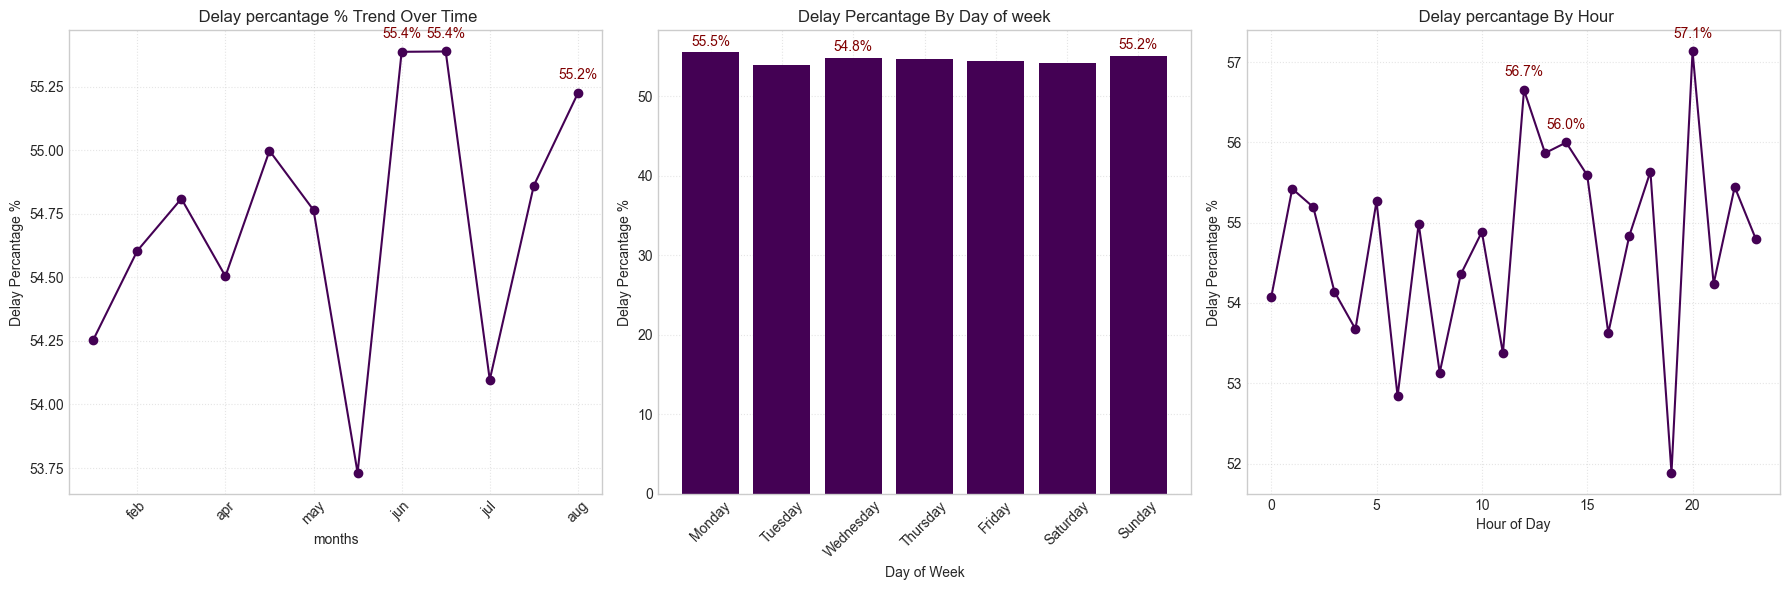

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (18, 6))

# subplot1 Delay % over month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker = 'o', color = primary_color)
ax.set_xticks(range(1,13))
ax1.set_xticklabels(['jan', 'feb', 'apr', 'may', 'jun', 'jul', 'aug', 'sept', 'oct', 'nov', 'dec'], rotation = 45)
ax1.set_xlabel('months')
ax1.set_ylabel('Delay Percantage %')
ax1.set_title(' Delay percantage % Trend Over Time')
ax1.grid(True, linestyle = ':', alpha = 0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                textcoords = 'offset points', xytext = (0, 10), ha = 'center', fontsize = 10, color = danger_color)
    
# subplot2 Delay % by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert to categorical
delay_by_week['order_week'] = pd.Categorical(
    delay_by_week['order_week'], 
    categories=day_order, 
    ordered=True
)

delay_by_week = delay_by_week.sort_values('order_week')

ax2.bar(delay_by_week['order_week'], delay_by_week['delay_pct'], color = primary_color)
ax2.set_xticklabels(delay_by_week['order_week'], rotation = 45)
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Delay Percantage %')
ax2.set_title('Delay Percantage By Day of week')
ax2.grid(True, linestyle = ':', alpha = 0.5)

# Annotate top 3 highest
top3_day = delay_by_week.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_week'], height + 0.5, f"{height:.1f}%", ha = 'center', va = 'bottom',fontsize = 10, color = danger_color)

# subplot3 Delay % by hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker = 'o', color = primary_color)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Delay Percantage %')
ax3.set_title(' Delay percantage By Hour')
ax3.grid(True, linestyle = ':', alpha = 0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                textcoords = 'offset points', xytext = (0, 10), ha = 'center', fontsize = 10, color = danger_color)

plt.tight_layout()
plt.savefig("timebasedupdated.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
delay_by_day

,order_day,Is_Delay,delay_pct
0,Mon,0.549749,54.974909
1,Tue,0.555942,55.594163
2,Wed,0.544701,54.470142
3,Thu,0.569817,56.981740
4,Fri,0.554683,55.468332
5,Sat,0.545966,54.596590
6,Sun,0.550086,55.008636
7,Mon,0.540061,54.006149
8,Tue,0.547294,54.729370
9,Wed,0.541862,54.186214


# Machine Learning Modeling

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [28]:
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode',  'order_month', 'order_hour']]
y = df['Late_delivery_risk']

In [29]:
cat_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
print('Categorical columns', cat_cols)


# Frequency encoding (low dimensional and rebust for high-cordinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize = True)
    X[f'{col}_freq'] = X[col].map(freq)

#keep numeric columns + new encoded features, drop original string catogeries
X_encoded = X.drop(columns = cat_cols)
print('Shape after frequency encoding:', X_encoded.shape)

# use encoded features for modeling
X = X_encoded

# train test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

Categorical columns ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after frequency encoding: (172765, 9)


In [30]:
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [31]:
# Balancing the training data using SMOTE
print('Before balancing (train)', Counter(y_train))

smote = SMOTE(random_state = 42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('After balancing (train):', Counter(y_train_bal))

Before balancing (train) Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [32]:
def evaluate_model(y_true, y_pred, model_name):
    print(f'\n--- {model_name} ---')
    print('Accuracy', round(accuracy_score(y_true, y_pred),2))
    print('Precision', round(precision_score(y_true, y_pred),2))
    print('Recall', round(recall_score(y_true, y_pred),2))
    print('\nClassification Report:\n', classification_report(y_true, y_pred))

In [33]:
# fit the random forest model to the balanced data
rf_model_balanced = RandomForestClassifier(random_state = 42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy 0.74
Precision 0.79
Recall 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553

